# Acceso a establecimientos de salud resolutivos en Perú

**Pregunta central:** ¿cuánto tiempo tarda, por carretera, la población en llegar
a un establecimiento con capacidad resolutiva (quirófano, cesárea)?

Este notebook es un **guion de exposición**, no el pipeline: solo lee lo que
`run_pipeline.py` ya calculó en `data/outputs/`. Ningún cómputo de ruteo ni de
métricas ocurre aquí — eso vive en `src/` para que sea cacheable, reusable y
testeable independientemente del notebook (issue #186, Fase 2: *"reruns no
deben recalcular"*).

**Alcance:** Tumbes (costa) · Huancavelica (andino) · Madre de Dios (amazónico).


In [1]:
import json
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from src import config

OUT = config.ruta("outputs")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

demanda = gpd.read_parquet(OUT / "demanda_metrics.parquet")
facilities = gpd.read_parquet(OUT / "facilities_validated.parquet")
quality_report = json.loads((OUT / "quality_report.json").read_text())
snap_report = json.loads((OUT / "snap_report.json").read_text())
summary = json.loads((OUT / "summary.json").read_text())
mode_comparison = pd.read_parquet(OUT / "mode_comparison.parquet")
sfca = pd.read_parquet(OUT / "sfca_2step.parquet")
isochrones = gpd.read_parquet(OUT / "isochrones.parquet")

print(f"{len(demanda)} puntos de demanda · {len(facilities)} establecimientos · "
      f"{facilities['resolutivo'].sum()} resolutivos activos")


576 puntos de demanda · 57 establecimientos · 30 resolutivos activos


## Fase 1 — Adquisición y validación

`src/acquisition.py` descarga RENIPRESS/SIGMED de forma idempotente; en este
entorno de desarrollo ambos portales bloquearon la IP del sandbox (403 /
conexión rechazada), documentado en `logs/acquisition.log`. Mientras se
resuelve el acceso desde una red sin ese bloqueo, el pipeline corre con datos
**sintéticos con errores inyectados a propósito** — nulos, lat/lon invertidos,
duplicados, puntos fuera de Perú — para poder probar `validation.py` de punta
a punta con casos reales de limpieza.


In [2]:
rows = []
for ds in quality_report["datasets"]:
    for regla in ds["reglas"]:
        rows.append({
            "dataset": ds["dataset"],
            "regla": regla["regla"],
            "accion": regla["accion"],
            "registros_afectados": regla["registros_afectados"],
        })
quality_df = pd.DataFrame(rows)
quality_df.pivot(index="regla", columns="dataset", values="registros_afectados").fillna(0).astype(int)


dataset,amazonico_demanda,amazonico_facilities,andino_demanda,andino_facilities,costa_demanda,costa_facilities
regla,,,,,,
codigos_duplicados,0,0,0,0,0,0
coordenadas_nulas_o_cero,4,1,4,1,4,1
encoding_utf8_vs_latin1,0,0,0,0,0,0
fuera_de_bbox_peru,4,0,4,0,4,0
lat_lon_invertidos,4,0,4,0,4,0
punto_fuera_de_poligono_distrital,0,0,0,0,0,0


Cada fila es una de las 6 reglas obligatorias del issue. La regla de
lat/lon invertidos **corrige** en vez de descartar (si el swap cae dentro del
bbox de Perú), y la de polígono distrital solo **marca** — puede ser un error
del polígono, no del punto — así que ninguna de las dos resta población real
de golpe.


## Fase 2 — Ruteo

Motor: OSMnx + NetworkX, **un grafo por departamento** (no nacional) — ver
`config.md: routing.motor`. Si Overpass no responde, el pipeline cae
automáticamente a un grafo geométrico sintético dentro del mismo bbox, para
que el resto del pipeline no dependa de que un servicio externo esté arriba.
Esta corrida usó:


In [3]:
fuente_rows = []
for rol, perfiles in snap_report["graph_sources"].items():
    for perfil, fuente in perfiles.items():
        fuente_rows.append({"departamento": rol, "perfil": perfil, "fuente_grafo": fuente})
pd.DataFrame(fuente_rows).pivot(index="departamento", columns="perfil", values="fuente_grafo")


perfil,bike,drive,walk
departamento,,,
amazonico,synthetic,synthetic,synthetic
andino,synthetic,synthetic,synthetic
costa,synthetic,synthetic,synthetic


`osm` = grafo real descargado de Overpass; `synthetic` = fallback documentado.
Es una decisión técnica defendible en la exposición: el pipeline no se cae
solo porque un servicio externo esté caído, y queda registrado exactamente
cuál de los dos se usó en cada corrida (ver `data/outputs/snap_report.json`).


In [4]:
snap_rows = []
for rol, perfiles in snap_report["snap"].items():
    for perfil, capas in perfiles.items():
        for capa, rep in capas.items():
            snap_rows.append({
                "departamento": rol, "perfil": perfil, "capa": capa,
                "snap_dist_m_promedio": round(rep["snap_dist_m_promedio"], 1) if rep["snap_dist_m_promedio"] else None,
                "n_sobre_umbral": rep["n_sobre_umbral"],
            })
pd.DataFrame(snap_rows).head(12)


,departamento,perfil,capa,snap_dist_m_promedio,n_sobre_umbral
0,costa,drive,demanda,1951.1,180
1,costa,drive,facilities,1679.6,5
2,costa,walk,demanda,1951.1,180
3,costa,walk,facilities,1679.6,5
4,costa,bike,demanda,1951.1,180
5,costa,bike,facilities,1679.6,5
6,andino,drive,demanda,5282.8,192
7,andino,drive,facilities,4539.4,5
8,andino,walk,demanda,5282.8,192
9,andino,walk,facilities,4539.4,5


## Fase 3 — Métricas\n\nKPIs agregados de las tres corridas de departamento:

In [5]:
print(f"Población total analizada: {summary['poblacion_total']:,}")
print(f"Puntos de demanda: {summary['n_demanda_total']}")
print(f"Gini ponderado del tiempo de acceso: {summary['gini_t_min_ponderado']:.3f}")
print(f"Correlación altitud-acceso (ponderada): r = {summary['cross_analysis_altitud']['r_ponderado']:.3f}")
print(summary['cross_analysis_altitud']['interpretacion'])


Población total analizada: 1,388,613
Puntos de demanda: 576
Gini ponderado del tiempo de acceso: 0.497
Correlación altitud-acceso (ponderada): r = -0.094
Correlacional, no causal: la altitud correlaciona con ruralidad y densidad vial, variables que este análisis no aísla.


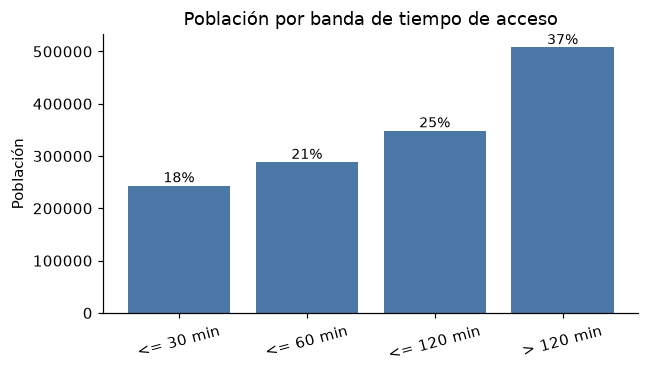

In [6]:
coverage = pd.read_csv(OUT / "coverage_bands.csv")
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(coverage["banda"], coverage["poblacion"], color="#4c78a8")
ax.set_ylabel("Población")
ax.set_title("Población por banda de tiempo de acceso")
for i, v in enumerate(coverage["pct_poblacion"]):
    ax.text(i, coverage["poblacion"].iloc[i], f"{v:.0f}%", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [7]:
critical = pd.read_csv(OUT / "critical_districts.csv")
critical.head(10)


,distrito,t_min_ponderado
0,MAD-3C,507.203810
1,MAD-2C,406.720385
2,MAD-3B,348.088990
3,HUA-3C,195.146425
4,HUA-2C,186.502408
5,MAD-1A,178.166527
6,MAD-2A,170.515703
7,MAD-2B,155.765831
8,MAD-1C,153.809903
9,HUA-3B,149.548027


Los distritos sintéticos de Madre de Dios (`MAD-*`) y Huancavelica (`HUA-*`)
dominan el top de peor acceso, y no es casualidad: sus bbox en `config.md`
cubren un área mucho mayor que la de Tumbes, así que incluso con la misma
densidad de nodos por grafo sintético, las distancias resultantes son más
largas. Es una señal geométrica esperable del propio setup sintético, no un
hallazgo sobre desigualdad real — la comparación que sí importa (Fase 2,
issue) es cuando estos mismos departamentos corran sobre la red vial real de
OSM.


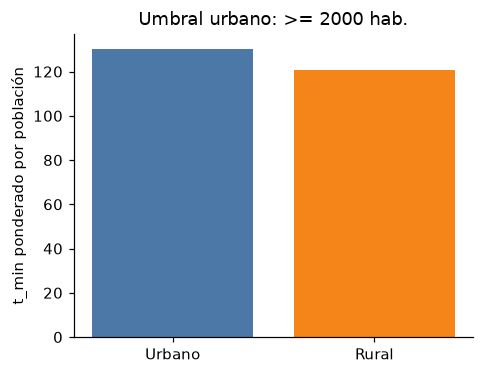

In [8]:
urban_rural = pd.read_csv(OUT / "urban_rural_contrast.csv")
fig, ax = plt.subplots(figsize=(4.5, 3.5))
labels = urban_rural["es_urbano"].map({True: "Urbano", False: "Rural"})
ax.bar(labels, urban_rural["t_min_ponderado"], color=["#4c78a8", "#f58518"])
ax.set_ylabel("t_min ponderado por población")
ax.set_title(f"Umbral urbano: >= {config.poblacion_minima_urbana()} hab.")
plt.tight_layout()
plt.show()


## Innovación 1 — Isócronas

Reutilizan el mismo grafo y la misma matriz de Fase 2: `nx.single_source_dijkstra`
desde la facility + alpha shape sobre los nodos alcanzables a 30/60/120 min. Cero
cómputo de ruteo nuevo, solo una vista distinta sobre datos que ya existían.


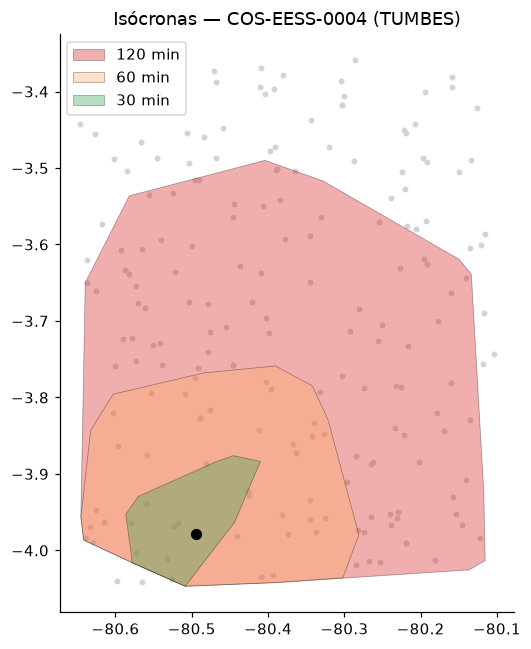

In [9]:
ejemplo_facility = isochrones["facility_id"].iloc[0]
sub = isochrones[isochrones["facility_id"] == ejemplo_facility].sort_values("threshold_min", ascending=False)
rol_ejemplo = facilities.loc[facilities["facility_id"] == ejemplo_facility, "departamento"].iloc[0]

fig, ax = plt.subplots(figsize=(6, 6))
demanda[demanda["departamento"] == rol_ejemplo].plot(ax=ax, markersize=8, color="lightgray", zorder=1)
colors = {30: "#31a354", 60: "#fdae61", 120: "#d7191c"}
for _, row in sub.iterrows():
    gpd.GeoSeries([row.geometry]).plot(ax=ax, alpha=0.35, color=colors.get(row["threshold_min"], "gray"),
                                        edgecolor="black", linewidth=0.5, zorder=2, label=f"{row['threshold_min']} min")
facilities[facilities["facility_id"] == ejemplo_facility].plot(ax=ax, color="black", markersize=40, zorder=3)
ax.set_title(f"Isócronas — {ejemplo_facility} ({rol_ejemplo})")
ax.legend()
plt.tight_layout()
plt.show()


## Innovación 2 — 2SFCA (Two-Step Floating Catchment Area)

Mide oferta disponible por habitante dentro del umbral de tiempo configurado
en `config.md: dos_sfca`, sumada sobre todas las facilities alcanzables —
reutiliza la matriz de Fase 2, no dispara ningún cómputo de ruteo nuevo.


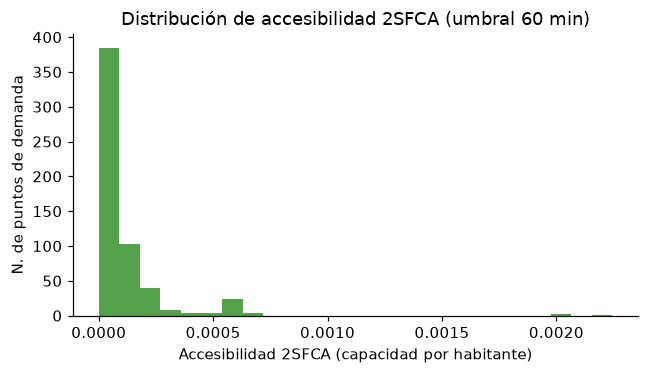

In [10]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(sfca["accesibilidad_2sfca"], bins=25, color="#54a24b")
ax.set_xlabel("Accesibilidad 2SFCA (capacidad por habitante)")
ax.set_ylabel("N. de puntos de demanda")
ax.set_title(f"Distribución de accesibilidad 2SFCA (umbral {config.dos_sfca_cfg()['threshold_min']} min)")
plt.tight_layout()
plt.show()


## Auto vs. caminar vs. bicicleta — el hallazgo que este pipeline puede probar
(y por qué esta corrida en particular NO lo prueba)

La hipótesis de trabajo, y la razón por la que `routing.compare_modes` existe:
el ratio tiempo-caminando/tiempo-en-auto debería ser mayor en Madre de Dios
(amazónico, red vial dispersa) que en Tumbes (costa, red densa) — evidencia de
desconexión de red vial, no solo de distancia.


In [11]:
mc = mode_comparison.merge(demanda[["cp_id", "departamento"]], on="cp_id", how="left")
resumen_ratio = mc.groupby("departamento")[["ratio_walk_drive", "ratio_bike_drive"]].median()
resumen_ratio


,ratio_walk_drive,ratio_bike_drive
departamento,,
HUANCAVELICA,6.0,2.0
MADRE DE DIOS,6.0,2.0
TUMBES,6.0,2.0


**Nota honesta, no un hallazgo:** en esta corrida los tres departamentos
cayeron al grafo sintético de respaldo (ver la tabla de `fuente_grafo` en
Fase 2 arriba) — por diseño, el generador sintético reutiliza la **misma
topología** para auto, caminar y bicicleta, y solo escala el tiempo de viaje
por una velocidad constante (`routing._FALLBACK_SPEED_KMH`). Eso fuerza
matemáticamente el ratio a ser una constante idéntica en los tres
departamentos (30/5 = 6.0 y 30/15 = 2.0), sin importar qué tan disperso sea el
grafo. No es ruido de muestra: es una propiedad estructural del modelo de
respaldo. El ratio dejará de ser constante — y podrá confirmar o refutar la
hipótesis — en cuanto el motor use la red vial real de OSM, donde las redes
peatonal y vehicular no son topológicamente idénticas (una tiene senderos que
la otra no, y viceversa).


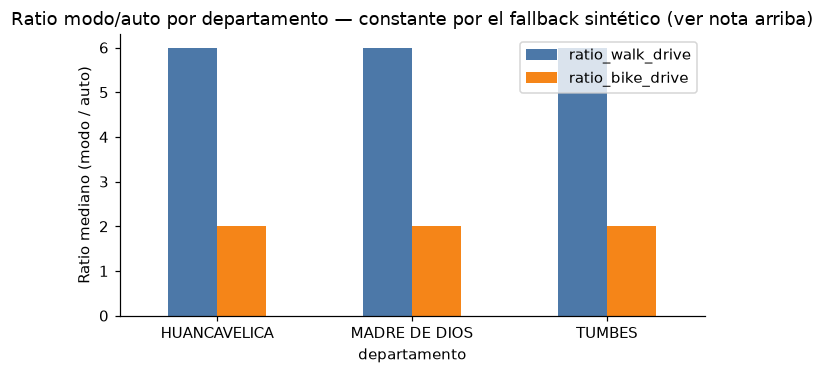

In [12]:
fig, ax = plt.subplots(figsize=(6, 3.5))
resumen_ratio.plot(kind="bar", ax=ax, color=["#4c78a8", "#f58518"])
ax.set_ylabel("Ratio mediano (modo / auto)")
ax.set_title("Ratio modo/auto por departamento — constante por el fallback sintético (ver nota arriba)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Simulador de escenario (demo en vivo)

El simulador de "upgrade" de establecimientos I-3/I-4 a categoría resolutiva
vive en el dashboard (`app.py`), no aquí: recalcula `t_min` **solo** para los
puntos que mejoran, reutilizando la matriz origen×facility ya precomputada —
sin llamar al motor de ruteo. Se demuestra en vivo durante el video.


## Limitaciones

- **Datos sintéticos.** RENIPRESS/SIGMED no fueron accesibles desde este
  entorno de desarrollo (bloqueo de red); las cifras de este notebook son
  ilustrativas del pipeline, no un diagnóstico real de acceso a salud en
  estos tres departamentos.
- **Grafo de ruteo con fallback sintético.** Cuando Overpass no respondió, se
  usó un grafo geométrico aleatorio como sustituto de la red vial real — las
  distancias/tiempos en ese caso no reflejan carreteras reales, solo permiten
  validar que el pipeline corre de punta a punta. Un efecto concreto de esto:
  el ratio caminar/auto y bici/auto sale **matemáticamente constante** entre
  departamentos (ver sección anterior) porque el grafo sintético usa la misma
  topología para los tres perfiles — esto se corrige solo con red vial real.
- **Altitud como proxy.** En datos sintéticos la altitud se generó con un
  gradiente espacial simple, no viene de un DEM real; la correlación
  altitud-acceso reportada aquí no debe leerse como hallazgo geográfico.
- **Tamaño de muestra.** 200 puntos de demanda y 20 facilities por
  departamento — suficiente para probar el pipeline, no para generalizar.
- Ninguna de estas limitaciones es de diseño: en cuanto se cargan datos
  reales (`python -m src.acquisition --real` desde una red sin el bloqueo),
  el mismo pipeline sin cambios produce resultados con significancia real.


## Conclusiones y próximos pasos

1. Validar con datos reales de RENIPRESS/SIGMED/OSM Perú.
2. Redactar `report/main.tex` con las cifras reales (las tablas ya se generan
   solas vía `src/export.py` en cada corrida del pipeline).
3. Grabar el video: framing del problema → este notebook como guion →
   demo en vivo del simulador de escenario en `app.py`.
